# 12 - Variables Categoricas con Muchos Niveles

Cuando una variable categorica tiene **muchos niveles** (ej. codigos postales, barrios, ciudades), crear dummies para cada nivel genera:

- **Demasiadas columnas** (80 codigos postales = 79 dummies)
- **Pocos datos por nivel** (algunos con 1-2 observaciones)
- **Overfitting** (el modelo memoriza ruido en lugar de aprender patrones)

La solucion: **consolidar niveles** agrupandolos de forma inteligente.

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Barrios unicos: {df['neighborhood'].nunique()}")
df.head()

Filas: 100, Columnas: 12
Barrios unicos: 25


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality,property_type,neighborhood
0,1,51,5,192700,2,1,2,4.7,0,5,Single Family,Centro Historico
1,2,52,44,132300,2,1,10,4.3,1,3,Apartment,La Merced
2,3,56,36,163200,2,1,1,6.6,1,6,Townhouse,La Merced
3,4,57,6,210100,3,2,8,14.0,1,5,Single Family,La Florida
4,5,58,21,109500,2,1,1,18.0,1,5,Apartment,Los Pinos


## 1. El problema: demasiadas dummies

Veamos que pasa si creamos dummies para los 25 barrios.

In [4]:
# Conteo de casas por barrio
counts = df["neighborhood"].value_counts().sort_values()
print(f"Barrios con <= 2 casas: {(counts <= 2).sum()}")
print(f"Barrios con <= 3 casas: {(counts <= 3).sum()}")
print()
print(counts.to_string())

Barrios con <= 2 casas: 6
Barrios con <= 3 casas: 11

neighborhood
Monte Verde         1
Los Olivos          1
Nuevo Horizonte     2
Plaza Mayor         2
El Bosque           2
Santa Rosa          2
El Carmen           3
El Prado            3
Villa Sol           3
Miraflores          3
La Esperanza        3
San Antonio         4
San Pedro           4
San Rafael          4
La Florida          4
Las Palmas          4
San Jose            5
Villa Verde         5
Las Flores          5
San Miguel          6
El Mirador          6
Los Pinos           6
Belen               7
La Merced           7
Centro Historico    8


In [7]:
# Si hacemos one hot encoding con drop='first': 24 columnas nuevas
encoder = OneHotEncoder(drop="first", sparse_output=False)
dummies = encoder.fit_transform(df[["neighborhood"]])
print(f"Datos: {df.shape[0]} filas")
print(f"Dummies generadas: {dummies.shape[1]} columnas")
print(f"\nProblema: {dummies.shape[1]} coeficientes solo para barrio")
print(f"Eso es {dummies.shape[1]} grados de libertad consumidos")
print(
    f"Con solo {df.shape[0]} filas, eso es ~1 coeficiente por cada {df.shape[0] // dummies.shape[1]} filas"
)

Datos: 100 filas
Dummies generadas: 24 columnas

Problema: 24 coeficientes solo para barrio
Eso es 24 grados de libertad consumidos
Con solo 100 filas, eso es ~1 coeficiente por cada 4 filas


## 2. Modelo base (sin barrio)

Primero entrenemos un modelo sin la variable `neighborhood` para tener una referencia.

In [9]:
predictors_num = ["square_meters", "bedrooms", "bathrooms", "build_quality"]
predictors_cat = ["property_type"]
all_predictors = predictors_num + predictors_cat
y = df["price"].to_numpy()

pipe_base = Pipeline(
    [
        (
            "preprocessor",
            ColumnTransformer(
                [
                    ("num", "passthrough", predictors_num),
                    ("cat", OneHotEncoder(drop="first"), predictors_cat),
                ]
            ),
        ),
        ("model", LinearRegression()),
    ]
)

scores_base = cross_val_score(pipe_base, df[all_predictors], y, cv=5, scoring="r2")
print(f"Modelo base (sin barrio):")
print(f"  R2 (CV): {scores_base.mean():.4f} (+/- {scores_base.std():.4f})")

Modelo base (sin barrio):
  R2 (CV): 0.2864 (+/- 0.2068)


## 3. Modelo con todos los barrios (25 niveles)

Ahora incluyamos `neighborhood` con todos sus niveles. Con 100 filas y 24 dummies extra, es probable que haya **overfitting**.

In [13]:
predictors_cat_full = ["property_type", "neighborhood"]
all_predictors_full = predictors_num + predictors_cat_full

pipe_full = Pipeline(
    [
        (
            "preprocessor",
            ColumnTransformer(
                [
                    ("num", "passthrough", predictors_num),
                    (
                        "cat",
                        OneHotEncoder(drop="first", handle_unknown="error"),
                        predictors_cat_full,
                    ),
                ]
            ),
        ),
        ("model", LinearRegression()),
    ]
)

# R2 en entrenamiento vs cross-validation
pipe_full.fit(df[all_predictors_full], y)
r2_train = pipe_full.score(df[all_predictors_full], y)

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_full = cross_val_score(
        pipe_full,
        df[all_predictors_full],
        y,
        cv=5,
        scoring="r2",
    )

print(f"Modelo con 25 barrios:")
print(f"  R2 (train): {r2_train:.4f}  <-- parece genial")

valid_scores = scores_full[~np.isnan(scores_full)]
if len(valid_scores) > 0:
    print(
        f"  R2 (CV):    {valid_scores.mean():.4f} (+/- {valid_scores.std():.4f})  <-- realidad"
    )
else:
    print(f"  R2 (CV):    FALLO en todos los folds")

print(f"\n  Folds exitosos: {len(valid_scores)}/5")
print(f"  Folds fallidos: {5 - len(valid_scores)}/5")
print(f"\nFalla porque barrios con 1-2 casas aparecen en el test pero no en el train.")
print(f"El encoder no reconoce categorias que nunca vio -> error.")

Modelo con 25 barrios:
  R2 (train): 0.8467  <-- parece genial
  R2 (CV):    0.0263 (+/- 0.4136)  <-- realidad

  Folds exitosos: 3/5
  Folds fallidos: 2/5

Falla porque barrios con 1-2 casas aparecen en el test pero no en el train.
El encoder no reconoce categorias que nunca vio -> error.


## 4. Explorando si la variable es util

Antes de consolidar, veamos si `neighborhood` realmente contiene informacion util sobre el precio.

In [14]:
# Precio mediano por barrio
median_price = (
    df.groupby("neighborhood")["price"].agg(["median", "count"]).sort_values("median")
)
print(median_price.to_string())

print(
    f"\nRango de medianas: ${median_price['median'].min():,.0f} - ${median_price['median'].max():,.0f}"
)
print(
    f"Diferencia: ${median_price['median'].max() - median_price['median'].min():,.0f}"
)

                    median  count
neighborhood                     
Miraflores        166900.0      3
Santa Rosa        173700.0      2
Los Olivos        175600.0      1
El Mirador        187900.0      6
La Florida        189800.0      4
Los Pinos         195700.0      6
La Merced         195900.0      7
Centro Historico  197150.0      8
Las Palmas        207700.0      4
Villa Verde       218800.0      5
La Esperanza      224600.0      3
San Pedro         256450.0      4
Villa Sol         268200.0      3
Las Flores        269200.0      5
San Miguel        280250.0      6
Belen             290700.0      7
Nuevo Horizonte   292200.0      2
Monte Verde       292900.0      1
San Rafael        301150.0      4
San Antonio       316450.0      4
El Bosque         325100.0      2
Plaza Mayor       329900.0      2
El Prado          356900.0      3
El Carmen         360400.0      3
San Jose          399400.0      5

Rango de medianas: $166,900 - $399,400
Diferencia: $232,500


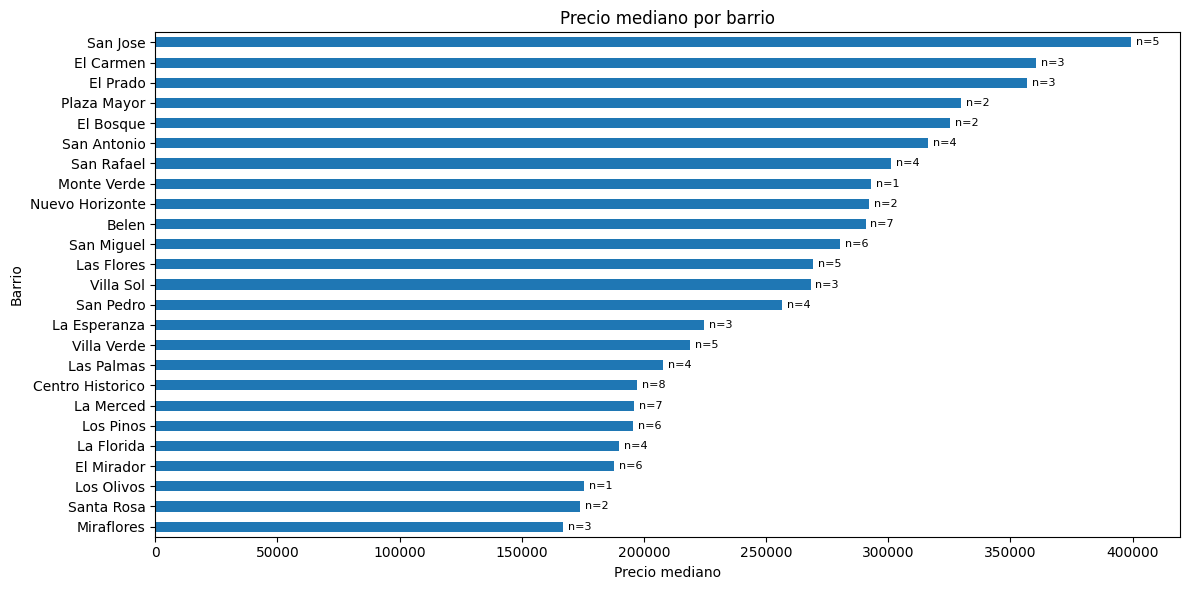

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
median_price["median"].plot(kind="barh", ax=ax)
ax.set_xlabel("Precio mediano")
ax.set_ylabel("Barrio")
ax.set_title("Precio mediano por barrio")
for i, (val, count) in enumerate(zip(median_price["median"], median_price["count"])):
    ax.text(val + 2000, i, f"n={count}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Estrategia 1: Consolidar por precio mediano

En vez de 25 barrios individuales, agrupamos en **grupos** segun el precio mediano. Esto reduce drasticamente el numero de dummies.

In [18]:
# Agrupar barrios en 5 grupos segun precio mediano
neighborhood_groups = df.groupby("neighborhood")["price"].median().sort_values()

# Usar qcut para dividir en 5 grupos
group_labels = pd.qcut(
    neighborhood_groups,
    q=5,
    labels=["Grupo_1_bajo", "Grupo_2", "Grupo_3", "Grupo_4", "Grupo_5_alto"],
)
neighborhood_to_group = group_labels.to_dict()

df["neighborhood_group"] = df["neighborhood"].map(neighborhood_to_group)

print("Barrios por grupo:")
for group in ["Grupo_1_bajo", "Grupo_2", "Grupo_3", "Grupo_4", "Grupo_5_alto"]:
    barrios = [k for k, v in neighborhood_to_group.items() if v == group]
    print(f"  {group}: {barrios}")

print(
    f"\nDe 25 barrios -> {df['neighborhood_group'].nunique()} grupos = {df['neighborhood_group'].nunique() - 1} dummies"
)

Barrios por grupo:
  Grupo_1_bajo: ['Miraflores', 'Santa Rosa', 'Los Olivos', 'El Mirador', 'La Florida']
  Grupo_2: ['Los Pinos', 'La Merced', 'Centro Historico', 'Las Palmas', 'Villa Verde']
  Grupo_3: ['La Esperanza', 'San Pedro', 'Villa Sol', 'Las Flores', 'San Miguel']
  Grupo_4: ['Belen', 'Nuevo Horizonte', 'Monte Verde', 'San Rafael', 'San Antonio']
  Grupo_5_alto: ['El Bosque', 'Plaza Mayor', 'El Prado', 'El Carmen', 'San Jose']

De 25 barrios -> 5 grupos = 4 dummies


In [19]:
# Modelo con barrios consolidados
predictors_cat_grouped = ["property_type", "neighborhood_group"]
all_predictors_grouped = predictors_num + predictors_cat_grouped

pipe_grouped = Pipeline(
    [
        (
            "preprocessor",
            ColumnTransformer(
                [
                    ("num", "passthrough", predictors_num),
                    ("cat", OneHotEncoder(drop="first"), predictors_cat_grouped),
                ]
            ),
        ),
        ("model", LinearRegression()),
    ]
)

pipe_grouped.fit(df[all_predictors_grouped], y)
r2_train_grouped = pipe_grouped.score(df[all_predictors_grouped], y)
scores_grouped = cross_val_score(
    pipe_grouped, df[all_predictors_grouped], y, cv=5, scoring="r2"
)

print(f"Modelo con barrios agrupados (5 grupos):")
print(f"  R2 (train): {r2_train_grouped:.4f}")
print(f"  R2 (CV):    {scores_grouped.mean():.4f} (+/- {scores_grouped.std():.4f})")

Modelo con barrios agrupados (5 grupos):
  R2 (train): 0.8083
  R2 (CV):    0.2523 (+/- 0.1865)


## 6. Estrategia 2: Consolidar por residuos (la del libro)

Esta es la estrategia **mas inteligente**. En vez de agrupar por precio directo, agrupamos por los **residuos** de un modelo base.

Los residuos capturan lo que el modelo **no puede explicar** con las otras variables. Si los residuos varian por barrio, el barrio agrega informacion nueva.

In [22]:
# Paso 1: entrenar modelo base (sin barrio)
pipe_base.fit(df[all_predictors], y)
residuals = y - pipe_base.predict(df[all_predictors])

# Paso 2: calcular mediana de residuos por barrio
df["residual"] = residuals
residual_by_neighborhood = (
    df.groupby("neighborhood")["residual"]
    .agg(["median", "count"])
    .sort_values("median")
)

print("Mediana de residuos por barrio:")
print("(positivo = el barrio encarece, negativo = abarata)")
print(residual_by_neighborhood.to_string())

Mediana de residuos por barrio:
(positivo = el barrio encarece, negativo = abarata)
                        median  count
neighborhood                         
Villa Sol        -47327.538948      3
El Mirador       -46077.403740      6
Las Flores       -36854.477567      5
Los Olivos       -32823.775067      1
Monte Verde      -25701.175570      1
La Esperanza     -25124.946294      3
Nuevo Horizonte  -22725.573994      2
Villa Verde      -21249.229153      5
Los Pinos        -20444.693432      6
San Pedro        -14605.958919      4
La Florida       -10202.357078      4
Las Palmas        -7411.626060      4
Santa Rosa        -2729.572583      2
San Antonio        -451.910696      4
San Rafael         -129.266978      4
Miraflores         3891.552224      3
San Miguel        11840.198843      6
Centro Historico  19454.308233      8
La Merced         21775.487387      7
El Carmen         22408.098972      3
El Prado          24290.292806      3
Plaza Mayor       27840.204122      2
El B

In [24]:
# Paso 3: agrupar barrios segun mediana de residuos
residual_medians = df.groupby("neighborhood")["residual"].median().sort_values()
residual_groups = pd.qcut(
    residual_medians,
    q=5,
    labels=["Zona_1_barata", "Zona_2", "Zona_3", "Zona_4", "Zona_5_cara"],
)
neighborhood_to_zone = residual_groups.to_dict()

df["neighborhood_zone"] = df["neighborhood"].map(neighborhood_to_zone)

print("Barrios por zona (basado en residuos):")
for zone in ["Zona_1_barata", "Zona_2", "Zona_3", "Zona_4", "Zona_5_cara"]:
    barrios = [k for k, v in neighborhood_to_zone.items() if v == zone]
    print(f"  {zone}: {barrios}")

Barrios por zona (basado en residuos):
  Zona_1_barata: ['Villa Sol', 'El Mirador', 'Las Flores', 'Los Olivos', 'Monte Verde']
  Zona_2: ['La Esperanza', 'Nuevo Horizonte', 'Villa Verde', 'Los Pinos', 'San Pedro']
  Zona_3: ['La Florida', 'Las Palmas', 'Santa Rosa', 'San Antonio', 'San Rafael']
  Zona_4: ['Miraflores', 'San Miguel', 'Centro Historico', 'La Merced', 'El Carmen']
  Zona_5_cara: ['El Prado', 'Plaza Mayor', 'El Bosque', 'Belen', 'San Jose']


In [25]:
# Modelo con zonas basadas en residuos
predictors_cat_zone = ["property_type", "neighborhood_zone"]
all_predictors_zone = predictors_num + predictors_cat_zone

pipe_zone = Pipeline(
    [
        (
            "preprocessor",
            ColumnTransformer(
                [
                    ("num", "passthrough", predictors_num),
                    ("cat", OneHotEncoder(drop="first"), predictors_cat_zone),
                ]
            ),
        ),
        ("model", LinearRegression()),
    ]
)

pipe_zone.fit(df[all_predictors_zone], y)
r2_train_zone = pipe_zone.score(df[all_predictors_zone], y)
scores_zone = cross_val_score(pipe_zone, df[all_predictors_zone], y, cv=5, scoring="r2")

print(f"Modelo con zonas por residuos (5 zonas):")
print(f"  R2 (train): {r2_train_zone:.4f}")
print(f"  R2 (CV):    {scores_zone.mean():.4f} (+/- {scores_zone.std():.4f})")

Modelo con zonas por residuos (5 zonas):
  R2 (train): 0.8428
  R2 (CV):    0.4625 (+/- 0.1810)


## 7. Comparacion de todas las estrategias

In [26]:
valid_full = scores_full[~np.isnan(scores_full)]
r2_full = valid_full.mean() if len(valid_full) > 0 else float("nan")

results = pd.DataFrame(
    {
        "Estrategia": [
            "Sin barrio",
            "25 barrios (todas las dummies)",
            "5 grupos (por precio mediano)",
            "5 zonas (por residuos)",
        ],
        "Dummies": [2, 24, 4, 4],
        "R2_CV": [
            scores_base.mean(),
            r2_full,
            scores_grouped.mean(),
            scores_zone.mean(),
        ],
    }
)

results["R2_CV"] = results["R2_CV"].round(4)
print(results.to_string(index=False))
print("\n--- Conclusion ---")
print("Las 25 dummies causan overfitting (R2 CV falla o es muy bajo)")
print("Consolidar en 5 zonas por residuos da el MEJOR resultado")

                    Estrategia  Dummies  R2_CV
                    Sin barrio        2 0.2864
25 barrios (todas las dummies)       24 0.0263
 5 grupos (por precio mediano)        4 0.2523
        5 zonas (por residuos)        4 0.4625

--- Conclusion ---
Las 25 dummies causan overfitting (R2 CV falla o es muy bajo)
Consolidar en 5 zonas por residuos da el MEJOR resultado


## 8. Visualizando por que los residuos son mejores

Agrupar por precio directo mezcla el efecto del tamano de la casa con el efecto del barrio. Los residuos **aislan** el efecto puro del barrio.

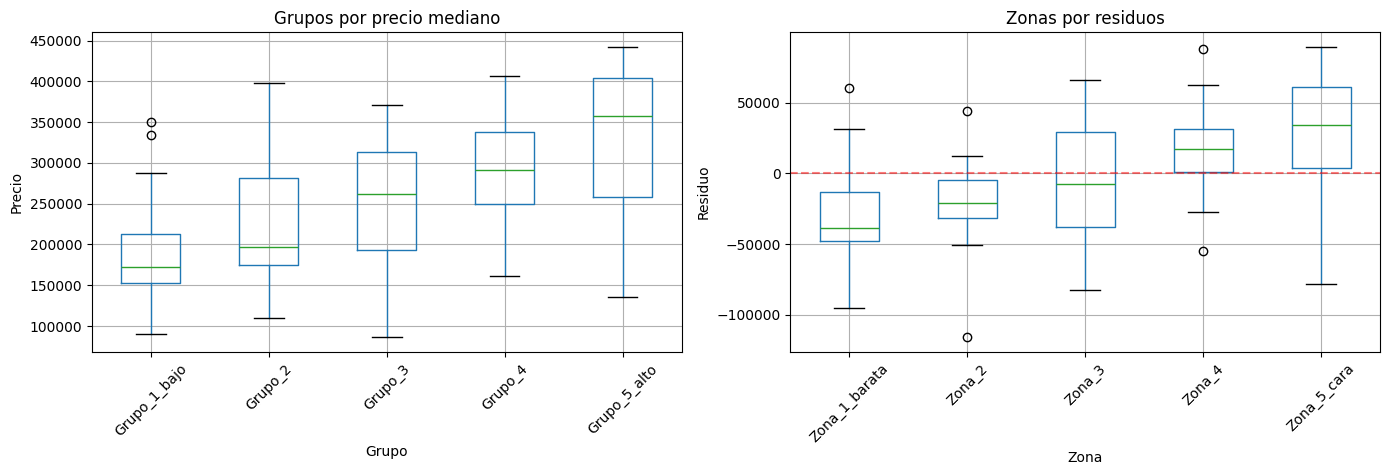

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por precio mediano
df.boxplot(column="price", by="neighborhood_group", ax=axes[0], vert=True)
axes[0].set_title("Grupos por precio mediano")
axes[0].set_xlabel("Grupo")
axes[0].set_ylabel("Precio")
axes[0].tick_params(axis="x", rotation=45)

# Por residuos
df.boxplot(column="residual", by="neighborhood_zone", ax=axes[1], vert=True)
axes[1].set_title("Zonas por residuos")
axes[1].set_xlabel("Zona")
axes[1].set_ylabel("Residuo")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5)

plt.suptitle("")
plt.tight_layout()
plt.show()

## 9. Resumen

| Concepto | Descripcion |
|----------|-------------|
| **Problema** | Muchos niveles = muchas dummies = overfitting |
| **Senales de alerta** | R2 train alto pero R2 CV bajo; niveles con 1-2 observaciones |
| **Estrategia 1** | Agrupar por precio mediano (simple pero mezcla efectos) |
| **Estrategia 2** | Agrupar por residuos del modelo base (aisla el efecto real del factor) |
| **Regla practica** | Si tienes mas de ~10 niveles con pocos datos, consolida |
| **Ventaja de residuos** | Capturan lo que el modelo NO explica, revelando el efecto puro del barrio |